# Comparison experiments


In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from functions import F_P, GradientKernel,KernelGradientDiscrepancy
import jax_kernels as ker
from extensible_sampling import ExtensibleSampling
from mfld import MeanFieldLangevinDynamics
from generalized_svgd import GeneralizedSVGD
from extensible_sampling import ExtensibleSampling
import functions as f

import jax
from jax import random

# 1. $\mathcal{L}$ is linear.

- $q_0(x) \propto \exp(-\|x\|^2/2)$
- $\mathcal{L}(Q)(x) = \int v(x) \ d Q(x)$, with $v(x) =  \frac{-\|x\|^2}{4}$


In this case, $\mathcal{L}'(Q)(x) = v(x)$ and $p(x) \propto e^{-\frac{\|x\|^2}{4}}$, so $P = \mathcal{N}(0,2 I_d)$.

KGD kernel :  IMQ   : $k(x,y) = \frac{1}{\sqrt{c + \|x-y\|^2}}$. 


<!-- F(q) = L(q) + Kl(q|q0) = L(q) + int -log q0 dq +int log q dq 
L(Q) = int v(x)dq
alors F(q) = int v(x)-log q0 dQ + int log q dq = KL(q|p) où p(x) propto q0 exp(v) = exp(-||x||^2/2 + v)


P(x) propto qO(x) exp(-L'(P)(x)) -->


In [8]:
results = {
    "MFLD": {
        "X_fin": None,
        "KGD": None
    },
    "Generalized SVGD": {
        "X_fin": None,
        "KGD_values": None
    },
    "ES": {
        "X_fin": None,
        "KGD_values": None
    },
    "VI": {
        "X_fin": None,
        "KGD_values": None
    }
}

In [9]:
c = 1
def k(x,y):
    return 1/jnp.sqrt((c + jnp.dot(x-y,x-y)))

def q_0(x):
    return jnp.exp(-jnp.linalg.norm(x)**2/2) #/ jnp.sqrt((2 *jnp.pi)**d)

def v(X):
    return -1/4 * jnp.linalg.norm(X, axis=1)**2 

def L(X):
    return jnp.mean(v(X))

k = jit(k)
q_0 = jit(q_0)
v = jit(v)
L = jit(L)

In [10]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)
F_P = f.F_P(q_0, L)
k_pq = f.GradientKernel(MFLD.S_PQ,k)
KGD = f.KernelGradientDiscrepancy(k_pq)

# Mean Field Langevin Dynamics

In [ ]:
MFLD = MeanFieldLangevinDynamics(q_0,L,k)

T = 1000
n = 100
d = 2
eta = 0.1 # the best stepsize 

key_init = random.PRNGKey(100)
key = random.PRNGKey(200)
X0 = random.normal(key_init, (n,d)) + 5 * jnp.ones((n, d))

all_particles = MFLD.run_particles(eta, T, X0,key)
results["MFLD"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))

results["MFLD"]["KGD"] = KGD


# Generalized SVGD

In [16]:
sigma_m = 5.0
m = lambda x,y : ker.k_gauss(x, y, sigma=sigma_m)
dm = lambda x,y : ker.dk_gauss(x, y, sigma=sigma_m)

G_SVGD = GeneralizedSVGD(q_0,L,k,m,dm)

T = 1000
n = 100
d = 2
eta = 2.0 # the best stepsize 

key_init = random.PRNGKey(100)
key = random.PRNGKey(200)
X0 = random.normal(key_init, (n,d)) + 5 * jnp.ones((n, d))

all_particles = G_SVGD.run_particles(eta, T, X0)
results["Generalized SVGD"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(all_particles[it]))

results["Generalized SVGD"]["KGD"] = KGD


# Extansible sampling 

In [18]:
ES = ExtensibleSampling(q_0,L,k)

T = 100
d = 2

key = random.PRNGKey(200)
x0 = random.normal(key, (d,)) 
X_fin = ES.run_particles(x0,T)

results["ES"]["X_fin"] = all_particles[-1]

KGD_values = jnp.zeros(T)
for it in range(T):
    KGD_values = KGD_values.at[it].set(KGD.evaluate(X_fin[:it+1]))

results["ES"]["KGD"] = KGD


Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62
Iteration: 63
Iteration: 64
Iteration: 65
Iteration: 66
Iteration: 67
Iteration: 68
Iteration: 69
Iteration: 70
Iteration: 71
Iteration: 72
I

dict_keys(['MFLD', 'Generalized SVGD', 'ES', 'VI'])

# Comparison of the experiments

Here we plot the final particles position obtained for each of the method. 

TypeError: 'NoneType' object is not subscriptable

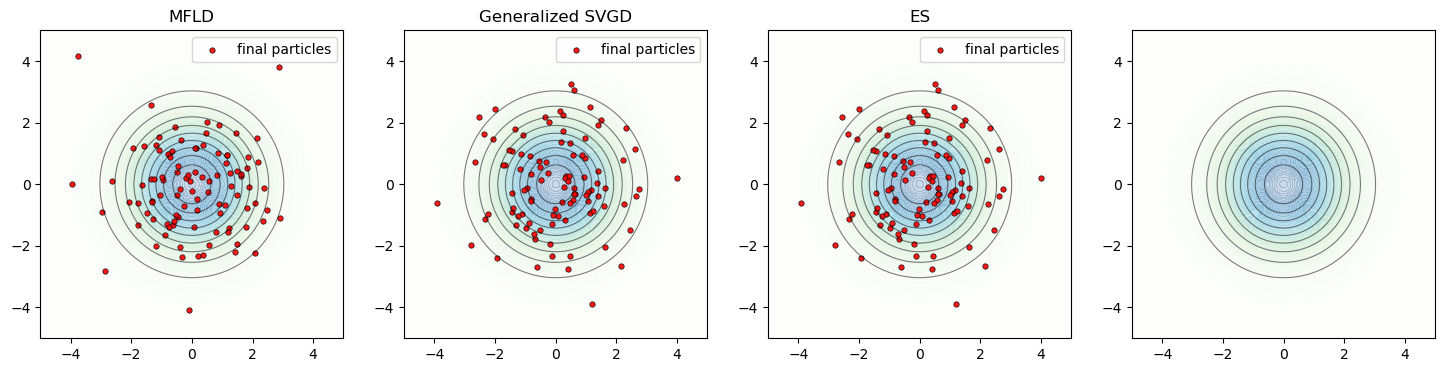

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ind, expe in enumerate(results.keys()):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.2     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.5
    )
    
    # Points très contrastés
    axes[ind].scatter(
        results[expe]["X_fin"][:, 0],
        results[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_xlim(-5, 5)
    axes[ind].set_ylim(-5, 5)
    axes[ind].set_title(expe)
    axes[ind].legend()

plt.tight_layout()
plt.show()